This notebook operationalises the concept of “textual attention” within a corpus of critical writing on Alexis Wright. The term is used to describe the extent to which particular theorists are not only cited, but actively mobilised as interpretive frameworks in the analysis of Wright’s work.

The study proceeds from the premise that citation alone is an insufficient indicator of intellectual influence. Bibliographies record presence, but they do not capture the distribution, intensity, or functional role of theoretical engagement within the body of a text. Accordingly, this notebook seeks to measure how attention is allocated across competing theoretical frames, and to distinguish between peripheral reference and sustained interpretive reliance.

Two primary research objectives guide the analysis. First, to identify the key theorists through whom Wright’s work is most frequently interpreted. Second, to quantify the degree of textual attention afforded to these figures, thereby establishing a comparative measure of their interpretive prominence.

Methodologically, the notebook combines corpus processing with frequency-based and positional analysis. Mentions of theorists are detected across the full text of each document, and weighted according to their distribution and recurrence. This enables a more nuanced account of critical engagement, capturing not only who is cited, but how substantially their frameworks shape scholarly readings of Wright’s fiction.


In [1]:
import os
import re
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import spacy

In [2]:
import spacy

nlp = spacy.load("en_core_web_trf")

In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "processed"

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")

documents = {}

for file in sorted(DATA_DIR.glob("*.txt")):
    text = file.read_text(encoding="utf-8").strip()
    if text:
        documents[file.stem] = text
    else:
        print(f"Skipping empty file: {file.name}")

print(f"Loaded {len(documents)} non-empty documents from {DATA_DIR}")

if not documents:
    raise ValueError("No documents were loaded. Check your data path and file contents.")

Loaded 85 non-empty documents from /Users/FMOR/Documents/GitHub/citational_refusal/data/processed


In [4]:
list(documents.keys())[:5]

['2007-01-01__coles-david__ngoonjook__carpentaria__book-review',
 '2007-01-01__syson-ian__overland__uncertain-magic__book-review',
 '2007-12-01__sharp-nonie__island__fiction__book-review',
 '2007__perlez-jane__new-york-times-book-review__aboriginal-lit-alexis-wright-carpentaria__book-review',
 '2008-01-01__devlin-glass-frances__australian-literary-studies__a-politics-of-the-dreamtime-destructive-and-regenerative-rainbows-in-alexis-wrights-carpentaria__journal-article']

In [5]:
doc_names = list(documents.keys())
doc_texts = list(documents.values())

processed_docs = []

total_docs = len(doc_texts)
print(f"Starting NER over {total_docs} documents...")

for i, doc in enumerate(nlp.pipe(doc_texts, batch_size=4), start=1):
    processed_docs.append(doc)

    if i % 5 == 0 or i == total_docs:
        print(f"Processed {i}/{total_docs} documents")

print(f"Finished processing {len(processed_docs)} documents.")

Starting NER over 85 documents...
Processed 5/85 documents
Processed 10/85 documents
Processed 15/85 documents
Processed 20/85 documents
Processed 25/85 documents
Processed 30/85 documents
Processed 35/85 documents
Processed 40/85 documents
Processed 45/85 documents
Processed 50/85 documents
Processed 55/85 documents
Processed 60/85 documents
Processed 65/85 documents
Processed 70/85 documents
Processed 75/85 documents
Processed 80/85 documents
Processed 85/85 documents
Finished processing 85 documents.


In [6]:
# Extract PERSON entities from each document
person_entities_by_doc = {}

for doc_name, doc in zip(doc_names, processed_docs):
    people = [ent.text.strip() for ent in doc.ents if ent.label_ == "PERSON"]
    person_entities_by_doc[doc_name] = people

sum(len(v) for v in person_entities_by_doc.values())

20559

In [7]:
sample_doc = doc_names[0]
person_entities_by_doc[sample_doc][:30]

['Wayne Nean',
 'Alexis\nWright',
 'David Coles',
 'Alexis Wright',
 'Alexis Wright',
 'Wright',
 'Danny',
 'Wright',
 'Charles Perkins',
 'Neville Whitmarsh',
 'David Coles',
 'the Freedom Riders',
 'David',
 'David Coles',
 'Phantom',
 'Normal Phanton',
 'Norm',
 'Norm',
 'Norm',
 'Cyclone',
 'Joseph',
 'Hemingway',
 'Norm Phantom',
 'Hemingway',
 'Wright',
 'Angel Day',
 'Norm',
 'Charlie',
 'Norm',
 'Mozzie']

Preliminary NER indicates many of the extracted names are characters from the novel. The analysis therefore excludes a defined set of names drawn from Carpentaria, including Normal Phantom, Angel Day, Will Phantom, Kevin Phantom, Mozzie Fishman, Joseph Midnight, Hope, Bala, Elias Smith, Stan Bruiser, Libby Valance, Captain Nicoli Finn, Uncle Micky, A.D. Smith, Sallyanne Smith, Lloydie Smith, Inso, Donny, Janice, Patsy, Girlie, Noelie, Tristum Fishman, Junior Fishman, Aaron Ho Kum, Conte, Chuck, Cookie, and Graham Spilling. These figures are omitted in order to remove narrative characters and locally situated actors from the dataset, thereby preventing the overrepresentation of fictional entities and enabling the analysis to focus more precisely on references to external scholars and interpretive authorities.

In [ ]:
# Normalise extarcted names

exclude_names = set([
    "",
    "alexis wright",
    "alexis wrights",
    "joseph",
    "jasal",
    "wright",
    "fishman",
    "mozzie fishman",
    "alexis",
    "alexis wright",
    "wright",
    "norm phantom",
    "mozzie fishman",
    "bobby",
    "max",
    "angel day",
    "danny",
    "phantom",
    "pricklebush",
    "will phantom",
    "joseph midnight",
    "hope",
    "oblivia",
    "carpentaria",
    "norm",
    "ivy",
    "will",
    "alexis",
    "normal",
    "angel",
    "mozzie",
    "will",
    "elias",
    "normal phantom",
    "elias smith",
    "joseph midnight"

])

def normalise_name(name):
    name = name.strip().lower()
    name = re.sub(r"\s+", " ", name)
    name = re.sub(r"[^\w\s\-']", "", name)
    return name

normalised_people_by_doc = {
    doc_name: [
        name for name in (normalise_name(n) for n in names)
        if name and name not in exclude_names
    ]
    for doc_name, names in person_entities_by_doc.items()
}

#flatten names into a list

all_people = [
    name
    for names in normalised_people_by_doc.values()
    for name in names
    if name and name not in exclude_names
]

print(f"Total normalised person mentions: {len(all_people)}")

Total normalised person mentions: 15639


In [9]:
name_counts = Counter(all_people)

top_people_df = pd.DataFrame(
    name_counts.most_common(50),
    columns=["person", "count"]
)

top_people_df.head(20)

,person,count
0,melville,124
1,glissant,122
2,shakespeare,94
3,ravenscroft,92
4,kevin,91
5,scott,87
6,langton,84
7,zhuangzi,74
8,miller,68
9,bruiser,52


Remove names and filter

In [ ]:
name_map = {
    "bhabha": "homi bhabha",
    "spivak": "gayatri spivak",
    "foucault": "michel foucault",
    "deleuze": "gilles deleuze",
    "guattari": "félix guattari",
    "butler": "judith butler",
    "ghosh": "amitav ghosh",
    "ravenscroft": "alison ravenscroft",
    "langton": "marcia langton",
    "leane": "jeanine leane",
    "rose": "deborah bird rose",
    "scott": "kim scott",
    




}

def apply_name_map(name, mapping):
    return mapping.get(name, name)

consolidated_people_by_doc = {
    doc_name: [
        apply_name_map(name, name_map)
        for name in names
        if apply_name_map(name, name_map) not in exclude_names
    ]
    for doc_name, names in normalised_people_by_doc.items()
}

all_consolidated_people = [
    name
    for names in consolidated_people_by_doc.values()
    for name in names
    if name and name not in exclude_names
]

consolidated_counts = Counter(all_consolidated_people)

consolidated_top_people_df = pd.DataFrame(
    consolidated_counts.most_common(50),
    columns=["person", "count"]
)

consolidated_top_people_df.head(25)

,person,count
0,melville,124
1,glissant,122
2,shakespeare,94
3,ravenscroft,92
4,kevin,91
5,scott,87
6,langton,84
7,zhuangzi,74
8,miller,68
9,bruiser,52


In [11]:
#diagnostic check 
print("alexis" in consolidated_counts)
print("normal" in consolidated_counts)
print("normal phantom" in consolidated_counts)
print(consolidated_counts.most_common(40))

False
False
False
[('melville', 124), ('glissant', 122), ('shakespeare', 94), ('ravenscroft', 92), ('kevin', 91), ('scott', 87), ('langton', 84), ('zhuangzi', 74), ('miller', 68), ('bruiser', 52), ('fishman', 50), ('brewster', 49), ('molly', 47), ('jasal', 47), ('houellebecq', 47), ('joseph', 46), ('bala', 46), ('alison ravenscroft', 45), ('mabo', 44), ('homi bhabha', 43), ('ghosh', 43), ('beckwith', 42), ('leane', 41), ('morrison', 40), ('bella donna', 40), ('michel foucault', 37), ('slemon', 36), ('lynda ng', 36), ('rose', 35), ('mudrooroo', 35), ('flanagan', 35), ('oodgeroo', 34), ('tom', 34), ('kim scott', 34), ('hess', 34), ('david', 33), ('herbert', 33), ('elizabeth', 33), ('howard', 33), ('derrida', 33)]


In [12]:
candidate_figures = [
    name for name, count in consolidated_counts.most_common(30)
]

print(f"Selected {len(candidate_figures)} candidate figures.")
print(candidate_figures[:20])

if not candidate_figures:
    raise ValueError("No candidate figures found. Check filtering and consolidation steps.")

Selected 30 candidate figures.
['melville', 'glissant', 'shakespeare', 'ravenscroft', 'kevin', 'scott', 'langton', 'zhuangzi', 'miller', 'bruiser', 'fishman', 'brewster', 'molly', 'jasal', 'houellebecq', 'joseph', 'bala', 'alison ravenscroft', 'mabo', 'homi bhabha']


In [13]:
def textual_attention_score(text, person_name):
    pattern = re.compile(r"\b" + re.escape(person_name) + r"\b", re.IGNORECASE)
    matches = list(pattern.finditer(text))
    freq = len(matches)

    if freq == 0:
        return 0.0

    positions = [m.start() for m in matches]

    if freq == 1:
        spread = 1
    else:
        spread = max(positions) - min(positions)

    text_length = max(len(text), 1)
    normalised_spread = spread / text_length

    return freq * normalised_spread

In [14]:
def clean_pdf_text(text):
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"([a-z])([A-Z])", r"\1 \2", text)
    return text.strip()

def chunk_text(text, chunk_size=2000):
    cleaned = clean_pdf_text(text)
    return [cleaned[i:i+chunk_size] for i in range(0, len(cleaned), chunk_size)]

def chunk_attention_score(text, person_name, chunk_size=2000):
    chunks = chunk_text(text, chunk_size=chunk_size)
    
    if not chunks:
        return 0.0
    
    pattern = re.compile(r"\b" + re.escape(person_name) + r"\b", re.IGNORECASE)
    matching_chunks = sum(1 for chunk in chunks if pattern.search(chunk))
    
    return matching_chunks / len(chunks)

In [17]:
# Compute frequency and attention per document

frequency_results = defaultdict(dict)
spread_attention_results = defaultdict(dict)
chunk_attention_results = defaultdict(dict)

total_docs = len(documents)
print(f"Scoring {total_docs} documents across {len(candidate_figures)} candidate figures...")

for i, (doc_name, text) in enumerate(documents.items(), start=1):
    for person in candidate_figures:
        pattern = re.compile(r"\b" + re.escape(person) + r"\b", re.IGNORECASE)
        matches = list(pattern.finditer(text))

        frequency_results[doc_name][person] = len(matches)
        spread_attention_results[doc_name][person] = textual_attention_score(text, person)
        chunk_attention_results[doc_name][person] = chunk_attention_score(text, person, chunk_size=2000)

    if i % 5 == 0 or i == total_docs:
        print(f"Scored {i}/{total_docs} documents")

print("Finished scoring all documents.")

Scoring 85 documents across 30 candidate figures...
Scored 5/85 documents
Scored 10/85 documents
Scored 15/85 documents
Scored 20/85 documents
Scored 25/85 documents
Scored 30/85 documents
Scored 35/85 documents
Scored 40/85 documents
Scored 45/85 documents
Scored 50/85 documents
Scored 55/85 documents
Scored 60/85 documents
Scored 65/85 documents
Scored 70/85 documents
Scored 75/85 documents
Scored 80/85 documents
Scored 85/85 documents
Finished scoring all documents.


In [20]:
# Convert result dictionaries into DataFrames

df_freq = pd.DataFrame.from_dict(frequency_results, orient="index").fillna(0)
df_spread_attention = pd.DataFrame.from_dict(spread_attention_results, orient="index").fillna(0)
df_chunk_attention = pd.DataFrame.from_dict(chunk_attention_results, orient="index").fillna(0)

print("Shapes:")
print("df_freq:", df_freq.shape)
print("df_spread_attention:", df_spread_attention.shape)
print("df_chunk_attention:", df_chunk_attention.shape)

Shapes:
df_freq: (85, 30)
df_spread_attention: (85, 30)
df_chunk_attention: (85, 30)


In [21]:
comparison_df = pd.DataFrame({
    "frequency": df_freq.sum(axis=0),
    "spread_attention": df_spread_attention.sum(axis=0),
    "chunk_attention": df_chunk_attention.sum(axis=0)
}).sort_values(by="chunk_attention", ascending=False)

print(f"Comparison table contains {len(comparison_df)} figures.")
comparison_df.head(20)

Comparison table contains 30 figures.


,frequency,spread_attention,chunk_attention
jasal,158,112.661633,6.501356
fishman,156,44.209960,5.994083
joseph,142,68.714416,5.301082
ravenscroft,155,114.096519,4.343483
scott,161,130.936333,3.701932
langton,126,95.316724,2.735597
brewster,92,60.169095,2.677995
kevin,120,53.998204,2.551695
mabo,111,82.217980,2.468160
rose,70,39.847580,2.437049


Chunk attention measures the proportion of fixed-length textual segments in which a given figure is mentioned. By segmenting the text into uniform units, this metric provides a robust approximation of the distribution of interpretive attention, independent of unreliable paragraph or formatting boundaries in PDF-derived corpora.

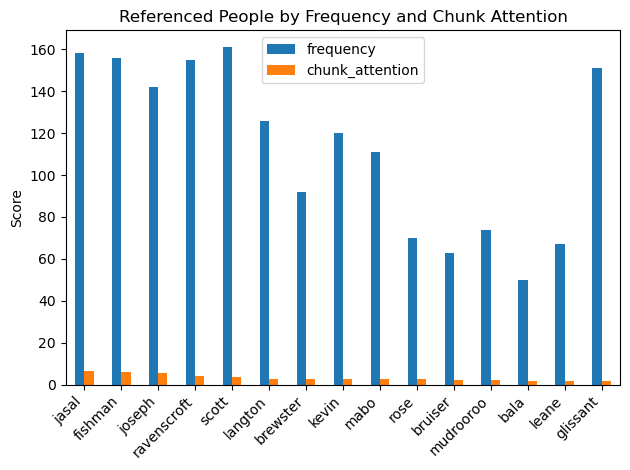

In [22]:
top_n = 15

comparison_df.head(top_n)[["frequency", "chunk_attention"]].plot(kind="bar")
plt.title("Referenced People by Frequency and Chunk Attention")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
dominant_figures_df = pd.DataFrame({
    "dominant_by_frequency": df_freq.idxmax(axis=1),
    "max_frequency": df_freq.max(axis=1),
    "dominant_by_spread_attention": df_spread_attention.idxmax(axis=1),
    "max_spread_attention": df_spread_attention.max(axis=1),
    "dominant_by_chunk_attention": df_chunk_attention.idxmax(axis=1),
    "max_chunk_attention": df_chunk_attention.max(axis=1),
})

dominant_figures_df.head(20)

,dominant_by_frequency,max_frequency,dominant_by_spread_attention,max_spread_attention,dominant_by_chunk_attention,max_chunk_attention
2007-01-01__coles-david__ngoonjook__carpentaria__book-review,joseph,2,joseph,0.465903,joseph,0.222222
2007-01-01__syson-ian__overland__uncertain-magic__book-review,bruiser,1,bruiser,0.000133,bruiser,0.250000
2007-12-01__sharp-nonie__island__fiction__book-review,joseph,2,joseph,0.499141,joseph,0.222222
2007__perlez-jane__new-york-times-book-review__aboriginal-lit-alexis-wright-carpentaria__book-review,melville,0,melville,0.000000,melville,0.000000
2008-01-01__devlin-glass-frances__australian-literary-studies__a-politics-of-the-dreamtime-destructive-and-regenerative-rainbows-in-alexis-wrights-carpentaria__journal-article,ravenscroft,2,ravenscroft,1.779908,ravenscroft,0.083333
2008-01-01__shoemaker-a__hecate__hard-dreams-and-indigenous-worlds-in-australias-north__journal-article,kevin,2,kevin,0.265300,kevin,0.200000
2008-01-01__torre-stephen__linq-literature-in-north-queensland__singing-the-country-afresh__book-review,bruiser,2,bruiser,0.328767,bruiser,0.333333
2008-05-01__ferrier-carole__journal-of-the-association-for-the-study-of-australian-literature__disappearing-memory-and-the-colonial-present-in-recent-indigenous-womens-writing__journal-article,jasal,9,jasal,7.789203,jasal,0.333333
2009-01-01__gleeson-white-j__meanjin__the-secret-life-of-stories__journal-article,rose,1,rose,0.000054,rose,0.100000
2009-01-01__jose-nicholas__journal-of-the-association-for-the-study-of-australian-literature__australian-literature-inside-and-out-barry-andrews-memorial-address__journal-article,miller,1,miller,0.000025,miller,0.050000


In [25]:
output_dir = PROJECT_ROOT / "outputs"
output_dir.mkdir(exist_ok=True)

top_people_df.to_csv(output_dir / "top_people_raw.csv", index=False)
consolidated_top_people_df.to_csv(output_dir / "top_people_consolidated.csv", index=False)

df_freq.to_csv(output_dir / "person_frequency_by_document.csv")
df_spread_attention.to_csv(output_dir / "person_spread_attention_by_document.csv")
df_chunk_attention.to_csv(output_dir / "person_chunk_attention_by_document.csv")

comparison_df.to_csv(output_dir / "person_corpus_comparison.csv")
dominant_figures_df.to_csv(output_dir / "dominant_figures_by_document.csv")

print(f"Saved outputs to {output_dir}")

Saved outputs to /Users/FMOR/Documents/GitHub/citational_refusal/outputs
